## All the imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from PIL import Image
import cv2
import imutils
import matlab.engine
import random
from gtda.homology import CubicalPersistence
from gtda.diagrams import PersistenceLandscape

# Start MATLAB
eng = matlab.engine.start_matlab()

In [130]:
import plotly.express as px

## Crop Function

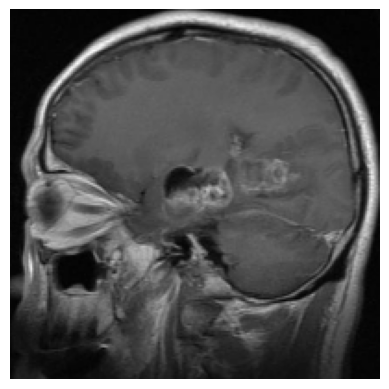

In [2]:
def crop_img(img):
	"""
	Finds the extreme points on the image and crops the rectangular out of them
	"""
	gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
	gray = cv2.GaussianBlur(gray, (3, 3), 0)

	# threshold the image, then perform a series of erosions +
	# dilations to remove any small regions of noise
	thresh = cv2.threshold(gray, 45, 255, cv2.THRESH_BINARY)[1]
	thresh = cv2.erode(thresh, None, iterations=2)
	thresh = cv2.dilate(thresh, None, iterations=2)

	# find contours in thresholded image, then grab the largest one
	cnts = cv2.findContours(thresh.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
	cnts = imutils.grab_contours(cnts)
	c = max(cnts, key=cv2.contourArea)

	# find the extreme points
	extLeft = tuple(c[c[:, :, 0].argmin()][0])
	extRight = tuple(c[c[:, :, 0].argmax()][0])
	extTop = tuple(c[c[:, :, 1].argmin()][0])
	extBot = tuple(c[c[:, :, 1].argmax()][0])
	ADD_PIXELS = 0
	new_img = img[extTop[1]-ADD_PIXELS:extBot[1]+ADD_PIXELS, extLeft[0]-ADD_PIXELS:extRight[0]+ADD_PIXELS].copy()
	
	return new_img

image_path = "/Users/sarthakkale/Documents/TDA/Code/MRI/Training/glioma/Tr-gl_0050.jpg"

# Load and preprocess the image
IMG_SIZE = 200
image = cv2.imread(image_path)

cropped = crop_img(image)
resized = cv2.resize(cropped, (IMG_SIZE, IMG_SIZE))
resized_rgb = cv2.cvtColor(resized, cv2.COLOR_BGR2RGB) #This step is necessary for displaying the image correctly in matplotlib (We will remove it when training for the whole folder)

# Show image in notebook
plt.imshow(resized_rgb)
plt.axis("off")
plt.show()

## Preprocessing Pt.1
- All the 4 folders will be preprocessed wrt to the crop function and resized.
- Results will be saved in a new preprocessed folder.

In [30]:
input_dir = "MRI/Training/glioma"
output_dir = "MRI/Training/glioma_preprocessed"
os.makedirs(output_dir, exist_ok=True)

IMG_SIZE = 256
for filename in os.listdir(input_dir):
    if filename.lower().endswith(".jpg"):
        image_path = os.path.join(input_dir, filename)
        image = cv2.imread(image_path)
        cropped = crop_img(image)
        resized = cv2.resize(cropped, (IMG_SIZE, IMG_SIZE))
        output_path = os.path.join(output_dir, filename)
        cv2.imwrite(output_path, resized)

In [31]:
input_dir = "MRI/Training/meningioma"
output_dir = "MRI/Training/meningioma_preprocessed"
os.makedirs(output_dir, exist_ok=True)

IMG_SIZE = 256
for filename in os.listdir(input_dir):
    if filename.lower().endswith(".jpg"):
        image_path = os.path.join(input_dir, filename)
        image = cv2.imread(image_path)
        cropped = crop_img(image)
        resized = cv2.resize(cropped, (IMG_SIZE, IMG_SIZE))
        output_path = os.path.join(output_dir, filename)
        cv2.imwrite(output_path, resized)

In [32]:
input_dir = "MRI/Training/notumor"
output_dir = "MRI/Training/notumor_preprocessed"
os.makedirs(output_dir, exist_ok=True)

IMG_SIZE = 256
for filename in os.listdir(input_dir):
    if filename.lower().endswith(".jpg"):
        image_path = os.path.join(input_dir, filename)
        image = cv2.imread(image_path)
        cropped = crop_img(image)
        resized = cv2.resize(cropped, (IMG_SIZE, IMG_SIZE))
        output_path = os.path.join(output_dir, filename)
        cv2.imwrite(output_path, resized)

In [33]:
input_dir = "MRI/Training/pituitary"
output_dir = "MRI/Training/pituitary_preprocessed"
os.makedirs(output_dir, exist_ok=True)

IMG_SIZE = 256
for filename in os.listdir(input_dir):
    if filename.lower().endswith(".jpg"):
        image_path = os.path.join(input_dir, filename)
        image = cv2.imread(image_path)
        cropped = crop_img(image)
        resized = cv2.resize(cropped, (IMG_SIZE, IMG_SIZE))
        output_path = os.path.join(output_dir, filename)
        cv2.imwrite(output_path, resized)

## Preprocessing Pt.2
- We will take first 40 images from the preprocessed folders.
- Pass the images to the NIVE.

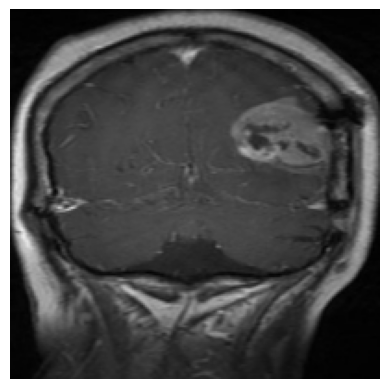

In [94]:
# Initialize a list to contain the first 44 images.
filenames = []

# Initialize a string containing the file path.
file_path = "MRI/Training/glioma_preprocessed/"

# Iterate through the folder and add the first 44 files to the list.
for i in range(10, 55):
  filenames.append(file_path + "Tr-gl_00" + str(i) + ".jpg")
  
# image_path = random.choice(filenames)
# print(image_path)
image_path = "MRI/Training/glioma_preprocessed/Tr-gl_0021.jpg"
image = cv2.imread(image_path)

resized = cv2.resize(image, (IMG_SIZE, IMG_SIZE))
resized_rgb = cv2.cvtColor(resized, cv2.COLOR_BGR2RGB) #This step is necessary for displaying the image correctly in matplotlib (We will remove it when training for the whole folder)

# Show image in notebook
plt.imshow(resized_rgb)
plt.axis("off")
plt.show()


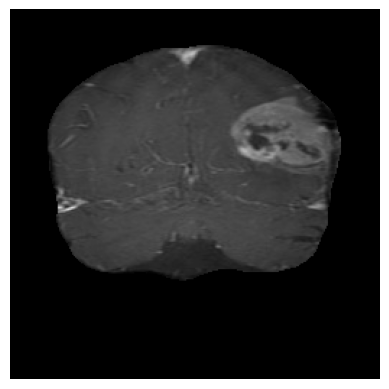

In [95]:
# Use current directory where notebook and .m/.mat files are located
eng.cd(os.getcwd(), nargout=0)
model_path = os.path.abspath("NIVE.mat")

# Run the MATLAB function
result = eng.nive_extract_brain(image_path, model_path)

# Convert MATLAB array to NumPy
# result is a 3D array in column-major (Fortran-style)
shape = tuple(result.size)  # (height, width, channels)
skull_np_array = np.array(result._data, dtype=np.uint8).reshape(shape, order='F')

# Display using matplotlib
plt.imshow(skull_np_array)
plt.axis('off')
plt.show()


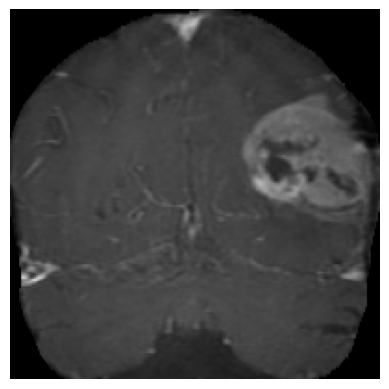

In [96]:
cropped_skull = crop_img(skull_np_array)
resized_skull = cv2.resize(cropped_skull, (200, 200), interpolation=cv2.INTER_AREA)
# Display the cropped and resized skull image
plt.imshow(resized_skull)
plt.axis('off')
plt.show()

## Performing TDA
- We will obtain the cubical persistence diagram for the skull-stripped images.
- We will obtain the persistence landscape for the skull-stripped images.

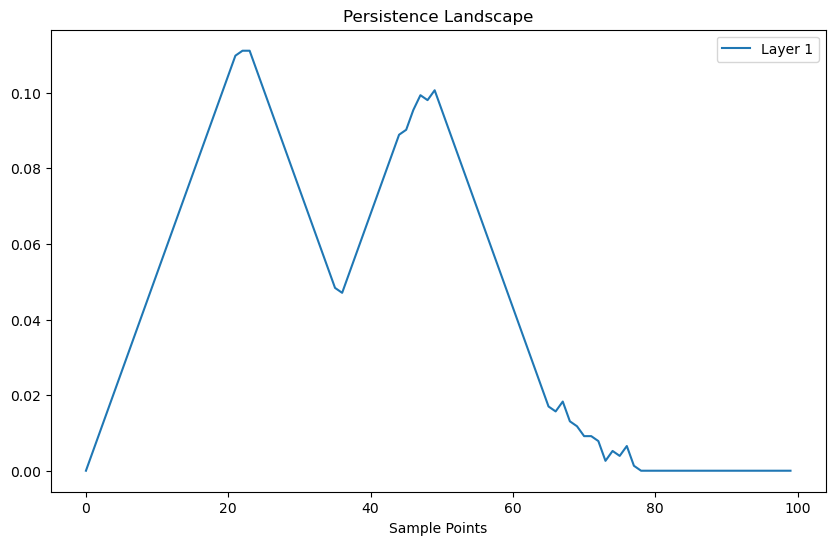

In [105]:
# Convert to grayscale for TDA
gray = cv2.cvtColor(resized_skull, cv2.COLOR_RGB2GRAY)  # MATLAB gives RGB by default
gray_normalized = gray / 255.0  # Normalize to [0,1]

# Replace black background with mid-gray instead of NaN
gray_normalized[gray_normalized == 0] = 0.5

# Reshape for giotto-tda
X = gray_normalized[np.newaxis, :, :]

# Compute cubical persistence
cp = CubicalPersistence(homology_dimensions=(0, 1))
cp.fit(X)
diagrams = cp.fit_transform(X)

# Plot the persistence diagram
fig = cp.plot(diagrams, sample=0)
fig.update_layout(title="Persistence Diagram (Skull-Stripped Image)")
fig.show()

# Compute persistence landscape
pl = PersistenceLandscape(n_layers=5) 
landscapes_original = pl.fit_transform(diagrams)

# Plot the persistence landscape
plt.figure(figsize=(10, 6))
#for i in range(min(5, landscapes.shape[1])): 
plt.plot(landscapes_original[0, 1], label=f'Layer {1}')
plt.xlabel("Sample Points")
plt.title("Persistence Landscape")
plt.legend()
plt.show()

## Perform CLAHE + TDA
- We will perform CLAHE on the skull-stripped images.
- We will obtain the cubical persistence diagram for the CLAHE images.
- We will obtain the persistence landscape for the CLAHE images.

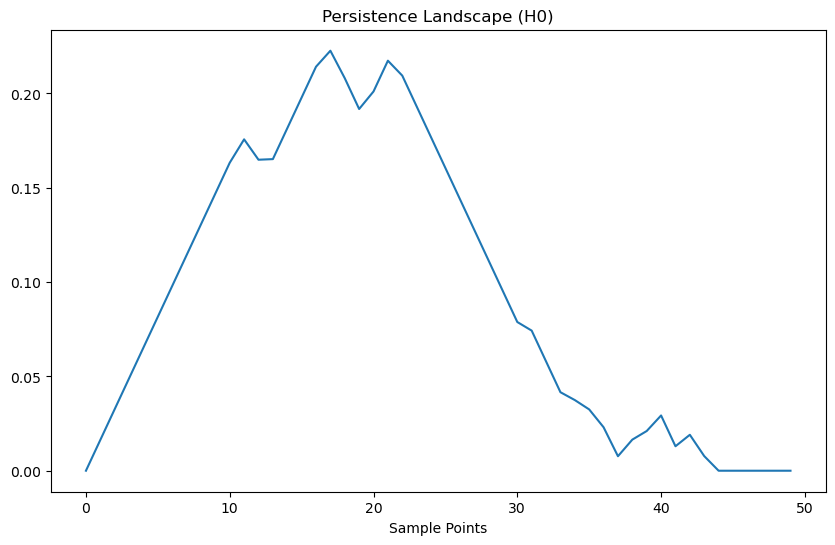

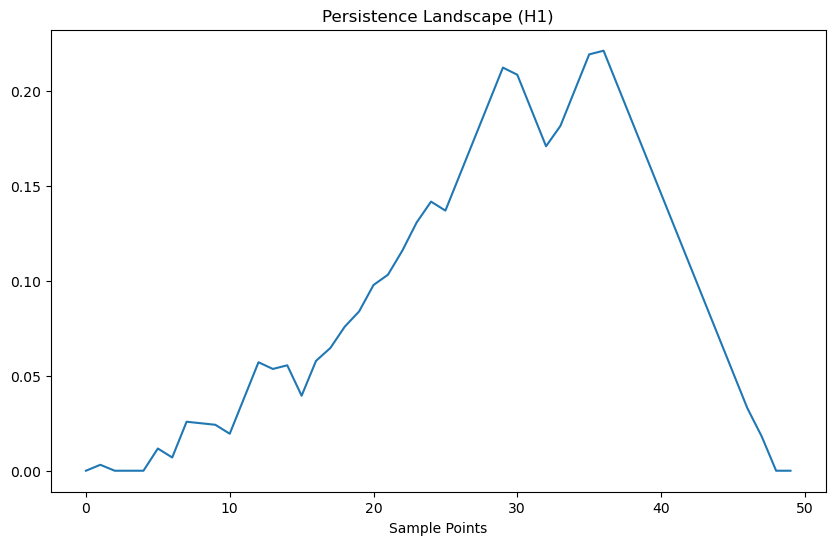

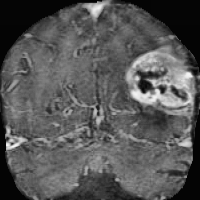

In [179]:
# Convert RGB to Grayscale
gray_skull_stripped = cv2.cvtColor(resized_skull, cv2.COLOR_RGB2GRAY)

# Apply CLAHE
clahe = cv2.createCLAHE(clipLimit=4.0, tileGridSize=(8, 8))
clahe_skull = clahe.apply(gray_skull_stripped)

# Normalize to [0, 1] for GTDA
normalized_clahe_skull = clahe_skull / 255.0
normalized_clahe_skull[normalized_clahe_skull < 0.02] = 0.5

# Reshape for giotto-tda
X_clahe_skull = normalized_clahe_skull[np.newaxis, :, :]  # Shape: (1, H, W)

# Compute Cubical Persistence
cp_skull = CubicalPersistence(homology_dimensions=(0, 1))
cp_skull.fit(X_clahe_skull)
diagrams_skull = cp_skull.fit_transform(X_clahe_skull)

#Plot the persistence diagram
diagram = diagrams_skull[0]
diagram_h0 = diagram[np.isclose(diagram[:, 2], 0)]
diagram_h1 = diagram[np.isclose(diagram[:, 2], 1)]

fig_h0 = px.scatter(x=diagram_h0[:, 0], y=diagram_h0[:, 1], labels={'x': 'Birth', 'y': 'Death'}, title='Persistence Diagram (H0)')
fig_h1 = px.scatter(x=diagram_h1[:, 0], y=diagram_h1[:, 1], labels={'x': 'Birth', 'y': 'Death'}, title='Persistence Diagram (H1)')
fig_h0.show()
fig_h1.show()


# Plot Persistence Diagram
# fig_skull = cp_skull.plot(diagrams_skull, sample=0)
# fig_skull.update_layout(title="Persistence Diagram (Skull-Stripped + CLAHE)")
# fig_skull.show()

# Compute persistence landscape
pl = PersistenceLandscape(n_layers=5, n_bins=50) 

#Plot Persistence Landscape for H0 
landscape_h0 = pl.fit_transform([diagram_h0])
plt.figure(figsize=(10, 6))
plt.plot(landscape_h0[0, 1])
plt.title("Persistence Landscape (H0)")
plt.xlabel("Sample Points")
plt.show()

#Plot Persistence Landscape for H1
landscape_h1 = pl.fit_transform([diagram_h1])
plt.figure(figsize=(10, 6))
plt.plot(landscape_h1[0, 1])
plt.title("Persistence Landscape (H1)")
plt.xlabel("Sample Points")
plt.show()

# Convert clahe_img to a PIL image
clahe_img = Image.fromarray(clahe_skull)

# Display the CLAHE image
clahe_img

## Feature Extraction
- We will extract the features from the persistence diagrams and landscapes.
- We will also create a persistence image and extract features from it.

In [162]:
clahe_skull[120:180]
for i in clahe_skull[120:180]:
    print(i[0:100])

[  4   4  26  35  48  58  71  95 108 108  99  95  95 103 110 112 111 105
 104  99  97  91  90  88  87  81  84 108 128 131 130 126 121 121 120 106
  83  94 102 107 115 119 115 109 105 100  99  95  90  85  85  88  97  92
  96  96  95  95  99 103 103 102 107 102  83  79  87 100 104  90  86  81
  85  93  93 102 105  92  96 113 112  95  81  81  76  49  55  79  93  80
  60  60  69  74  75 106 170 189 194 186]
[  4   4  20  26  42  51  64  85 102 106  97  85  85  97 104 111 109 104
 103  97  96  94  84  83  90  85  88  99 111 117 116 107  97 105 112 110
  96 104 108 107 107 111 106 106 105  96  95  95  95  98  94  93  97 106
 110 110 100  91  90  90  94  94  98  93  88  83  92 105 109 100  95  94
  94  98  98 106 105  97 101 108 108  86  77  77  81  80  80  93  93  76
  60  64  74 100  84  93 158 181 188 180]
[  4   4  16  19  37  47  60  83 108 108  91  87  87  91  98 114 108  98
  97  92  86  93  83  82  90  88  87  90 102 109 108  98  88 100 112 111
 101 104 103 103 103 107 102 106 105 100

In [180]:
# Convert the persistence landscape to a feature vector
features_h0 = landscape_h0[0].flatten()
features_h1 = landscape_h1[0].flatten()

print("Features Vector Length:", len(features_h0))
print("Features Vector Length:", len(features_h1))

###############################
#Consider masking in terms of decreasing order.

Features Vector Length: 250
Features Vector Length: 250


In [181]:
#print("H0 Features:", features_h0)
print(sorted(features_h0, reverse=True)[:50])  


[0.27162865146058424, 0.2610644257703082, 0.25530212084833936, 0.2447378951580632, 0.24097639055622244, 0.2407362945178072, 0.2389755902360945, 0.22841136454581834, 0.22464985994397757, 0.22440976390556233, 0.2226490596238495, 0.21736694677871138, 0.21416566626650657, 0.21208483393357347, 0.2094437775110044, 0.20936374549819936, 0.20832332933173264, 0.20808323329331735, 0.20632252901160464, 0.2010404161664665, 0.19891956782713094, 0.1978391356542617, 0.1978391356542617, 0.1978391356542617, 0.1957583033213286, 0.19311724689875953, 0.1930372148859545, 0.19199679871948774, 0.19175670268107248, 0.18999599839935977, 0.18471388555422164, 0.18259303721488596, 0.18191276510604248, 0.18151260504201683, 0.18151260504201683, 0.18151260504201683, 0.1795918367346939, 0.17943177270908373, 0.17679071628651466, 0.1767106842737095, 0.17567026810724287, 0.1754301720688276, 0.1736694677871149, 0.16838735494197676, 0.16626650660264108, 0.1655862344937976, 0.1651860744297719, 0.1651860744297719, 0.16518607

In [185]:
from skimage.feature import graycomatrix, graycoprops


In [182]:

# Parameters
distances = [1, 2, 3]
angles = [0, np.pi/4, np.pi/2, 3*np.pi/4]
#properties = ['energy', 'homogeneity']
properties = ['contrast', 'correlation', 'dissimilarity', 'energy']

# Compute GLCM
glcm = graycomatrix(clahe_skull, distances=distances, angles=angles, levels=256, symmetric=True, normed=True)

# Extract features
glcm_features = []
for prop in properties:
    vals = graycoprops(glcm, prop)  
    glcm_features.extend(vals.flatten())

glcm_features = np.array(glcm_features)
print("GLCM Features:", glcm_features)
print("GLCM feature vector length:", len(glcm_features))  

#combined_features = np.concatenate((glcm_features, features_vector)) 



GLCM Features: [1.54967789e+02 3.02025858e+02 1.84415553e+02 3.08562663e+02
 4.52985455e+02 3.02025858e+02 4.92720126e+02 3.08562663e+02
 7.56450711e+02 7.32997475e+02 7.73536878e+02 7.56007780e+02
 9.63055130e-01 9.27506666e-01 9.56134240e-01 9.25937678e-01
 8.91076962e-01 9.27506666e-01 8.82066903e-01 9.25937678e-01
 8.16562315e-01 8.21340540e-01 8.13782376e-01 8.15732051e-01
 7.45336683e+00 1.08317972e+01 8.43424623e+00 1.09134113e+01
 1.31668687e+01 1.08317972e+01 1.40246717e+01 1.09134113e+01
 1.71801523e+01 1.71197582e+01 1.76141371e+01 1.72741302e+01
 9.44335528e-02 9.02819715e-02 9.51357167e-02 9.03465092e-02
 8.78799380e-02 9.02819715e-02 8.97119799e-02 9.03465092e-02
 8.23756957e-02 8.12734922e-02 8.53662574e-02 8.13477197e-02]
GLCM feature vector length: 48


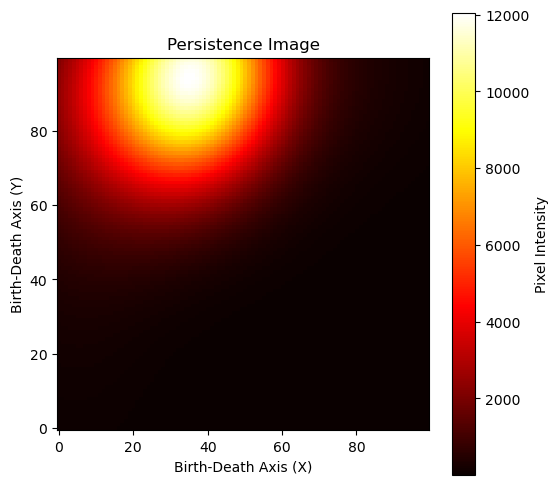

Features Vector Length: 20000
Features Vector: [ 60.07551936  61.52773801  62.66286839 ... 530.61069261 486.30942323
 443.70940412]


In [111]:
from gtda.diagrams import PersistenceImage

# Create the persistence image transformer and compute the features
pimg = PersistenceImage()
features = pimg.fit_transform(diagrams_skull)

# Extract the 2D persistence image
persistence_image = features[0][0]

# Plot the persistence image
plt.figure(figsize=(6, 6))
plt.imshow(persistence_image, cmap='hot', interpolation='nearest', origin='lower')
plt.title("Persistence Image")
plt.colorbar(label='Pixel Intensity')
plt.xlabel("Birth-Death Axis (X)")
plt.ylabel("Birth-Death Axis (Y)")
plt.show()

#Flatten the persistence image to a 1D feature vector
features_vector = features[0].flatten()  
print("Features Vector Length:", len(features_vector))
print("Features Vector:", features_vector)  

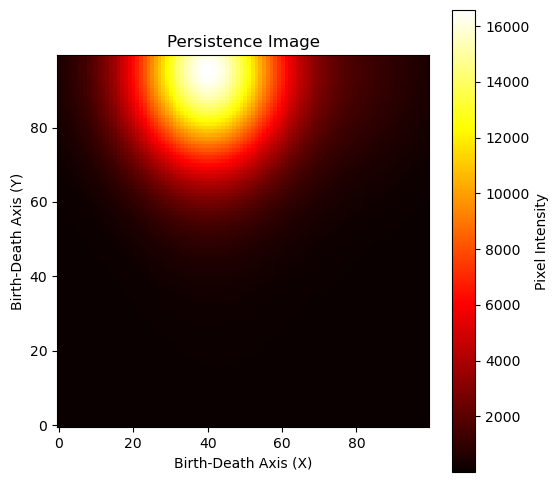

Features Vector Length: 20000
Features Vector: [ 60.07551936  61.52773801  62.66286839 ... 530.61069261 486.30942323
 443.70940412]


In [112]:
from gtda.diagrams import PersistenceImage

# Create the persistence image transformer and compute the features
pimg = PersistenceImage()
features = pimg.fit_transform(diagrams_skull)

# Extract the 2D persistence image
persistence_image = features[0][1]

# Plot the persistence image
plt.figure(figsize=(6, 6))
plt.imshow(persistence_image, cmap='hot', interpolation='nearest', origin='lower')
plt.title("Persistence Image")
plt.colorbar(label='Pixel Intensity')
plt.xlabel("Birth-Death Axis (X)")
plt.ylabel("Birth-Death Axis (Y)")
plt.show()

#Flatten the persistence image to a 1D feature vector
features_vector = features[0].flatten()  
print("Features Vector Length:", len(features_vector))
print("Features Vector:", features_vector)  

In [113]:
diagram = diagrams_skull[0]  

# Extract each dimension
H0_elements = diagram[diagram[:, 2] == 0]
H1_elements = diagram[diagram[:, 2] == 1]

# Print counts
print("Number of H0 features (connected components):", len(H0_elements))
print("Number of H1 features (loops):", len(H1_elements))

Number of H0 features (connected components): 1176
Number of H1 features (loops): 1503


In [114]:
print("Min pixel value after CLAHE:", normalized_clahe_skull.min())
print("Unique pixel values (sample):", np.unique(normalized_clahe_skull)[:10])
#Think about OTSU thresholding

Min pixel value after CLAHE: 0.023529411764705882
Unique pixel values (sample): [0.02352941 0.02745098 0.03137255 0.03529412 0.03921569 0.04313725
 0.04705882 0.05098039 0.05490196 0.05882353]


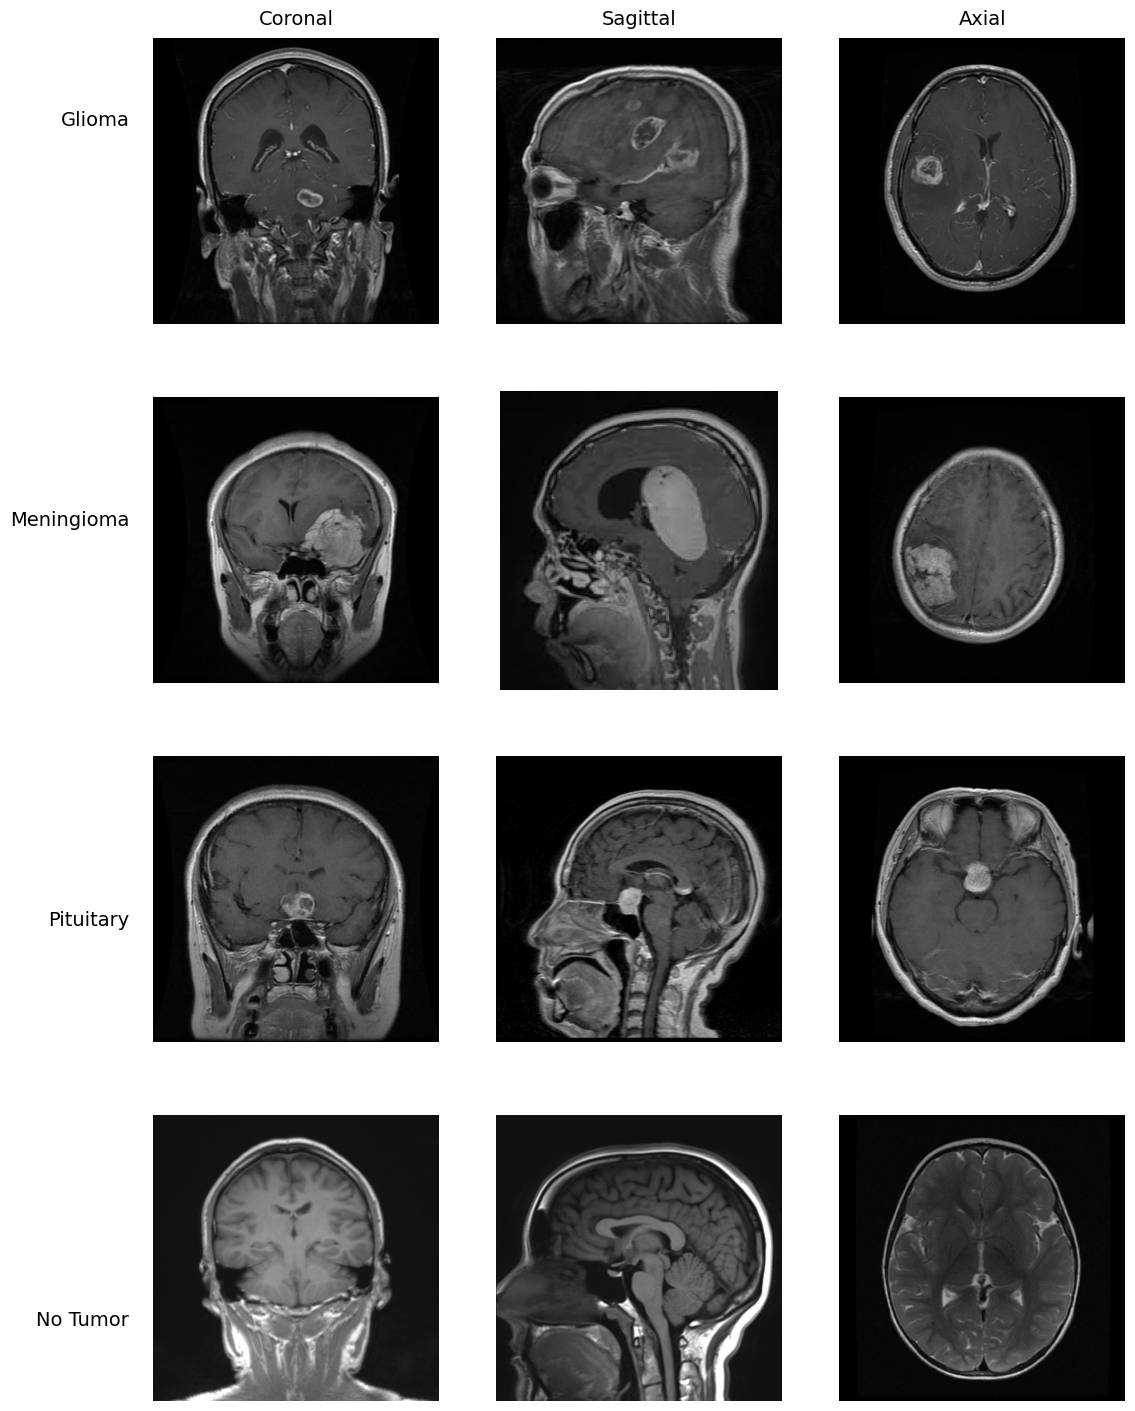

In [85]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

# === 1. Define your 12 image paths (row-wise order) ===
image_paths = [
    "MRI/Training/glioma/Tr-gl_0014.jpg",
    "MRI/Training/glioma/Tr-gl_0040.jpg",
    "MRI/Training/glioma/Tr-gl_0051.jpg",
    "MRI/Training/meningioma/Tr-me_0017.jpg",
    "MRI/Training/meningioma/Tr-me_0206.jpg",
    "MRI/Training/meningioma/Tr-me_0010.jpg",
    "MRI/Training/pituitary/Tr-pi_0010.jpg",
    "MRI/Training/pituitary/Tr-pi_0035.jpg",
    "MRI/Training/pituitary/Tr-pi_0112.jpg",
    "MRI/Training/notumor/Tr-no_0022.jpg",
    "MRI/Training/notumor/Tr-no_0019.jpg",
    "MRI/Training/notumor/Tr-no_0013.jpg",
]

# === 2. Define labels ===
row_labels = ["Glioma", "Meningioma", "Pituitary", "No Tumor"]
col_labels = ["Coronal", "Sagittal", "Axial"]

# === 3. Grid dimensions ===
rows, cols = 4, 3
total_cells = rows * cols

# === 4. Pad image_paths if fewer than total_cells ===
while len(image_paths) < total_cells:
    image_paths.append(None)

# === 5. Create subplots ===
fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 4))

for i, ax in enumerate(axes.flat):
    img_path = image_paths[i]

    if img_path and os.path.exists(img_path):
        img = mpimg.imread(img_path)
        ax.imshow(img)
    else:
        ax.set_facecolor("lightgray")

    ax.axis('off')

    row = i // cols
    col = i % cols

    # Add column titles on the top row
    if row == 0:
        ax.set_title(col_labels[col], fontsize=14, pad=10)

# === 6. Add row labels using fig.text ===
# Increase x from 0.03 → 0.07 to bring labels closer
for r in range(rows):
    ypos = 1 - (r + 0.5) / rows
    fig.text(0.15, ypos, row_labels[r], va='center', ha='right', fontsize=14)

# === 7. Adjust layout for spacing (reduce left margin a bit)
plt.subplots_adjust(left=0.17, right=0.98, top=0.93, bottom=0.07)
plt.savefig("brain_tumor_images_grid.png", bbox_inches='tight', dpi=300)
plt.show()


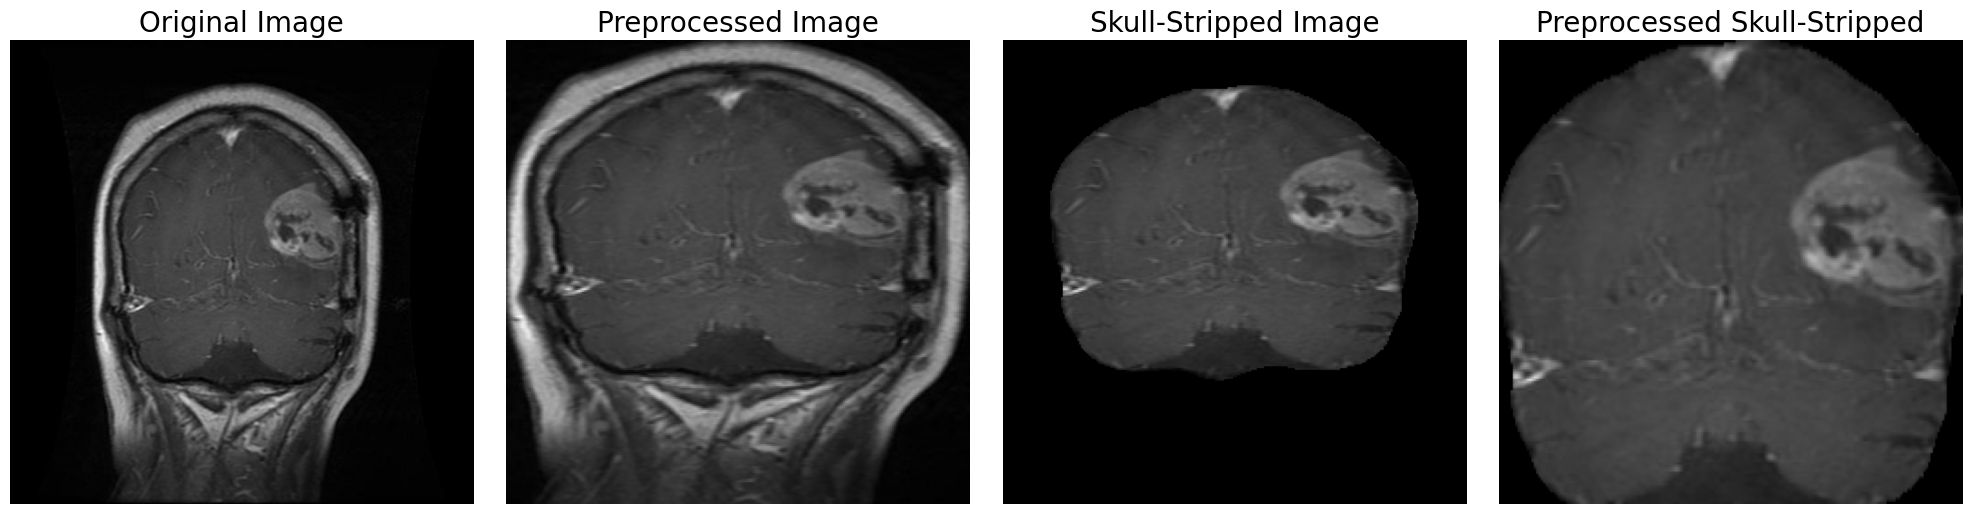

In [99]:

# === 1. Store the images and titles in a list ===
images = [
    ("Original Image", cv2.imread("MRI/Training/glioma/Tr-gl_0021.jpg")),
    ("Preprocessed Image", image),
    ("Skull-Stripped Image", skull_np_array),
    ("Preprocessed Skull-Stripped", resized_skull)
]

# === 2. Create 1-row, 4-column subplot ===
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

# === 3. Loop through each image and display ===
for ax, (title, img) in zip(axes, images):
    ax.imshow(img, cmap='gray')  # Use 'gray' if images are grayscale
    ax.set_title(title, fontsize=20)
    ax.axis('off')

plt.tight_layout()
plt.savefig("brain_tumor_images_comparison.png", bbox_inches='tight', dpi=300)
plt.show()
